# Todo

* Make sure to transfer all the model outputs for future processing or back reference
* Get a feel of cell types tend to be the runner up to what primary cell types the most


# Packages

In [1]:
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import os
import spatialdata as spd

from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Data

# Locations

In [2]:
# setting up addresses

# proj_folder       = Path("/coh_labs/yunroseli/Jona/CAR-T/results/cell2location/FirstPass/") # Cohorts
# proj_folder       = Path("/home/janzules/spatial/CAR-T/data/cell2location") # Gemini - first pass files
# proj_folder     = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/cell2location/")
proj_folder   = Path("/coh_labs/yunroseli/Jona/CAR-T/") # Most up to date files

out_figs          = proj_folder / "figures/manual_qc"
adata_out_folder  = proj_folder / "annotated_adata"
adata_out_folder.mkdir(exist_ok=True)
out_figs.mkdir(exist_ok=True)
# Files
# zarr_file         = proj_folder / "data/zarr/CellCharterClusters"
adata_ref         = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/annotating_references/predicted_cells_lvl2_epochs_200_Ncells1_decalpha_100_posterior400_bs8192.h5ad"
# adata_ref        = proj_folder / "results/cell2location/C2L_inputs/predicted_cells_lvl2_epochs_200_Ncells1_decalpha_100.h5ad"
# adata_out         = adata_out_folder / "sp_200_epochs_defaultalpha.h5ad" # moved to the save section under annotation



## Processing data

In [3]:
# Load data
adata_vis = sc.read_h5ad(adata_ref)
# zdata = spd.read_zarr(zarr_file)

In [4]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

def normalize_celltype_cols(df: pd.DataFrame) -> pd.DataFrame:
    # strips everything up to and including "_sf_" so columns become just: T_cell, NK_cell, ...
    new_cols = [re.sub(r"^.*?_sf_", "", c) for c in df.columns]
    out = df.copy()
    out.columns = new_cols
    return out

means_df = normalize_celltype_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
q05_df   = normalize_celltype_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])
q95_df   = normalize_celltype_cols(adata_vis.obsm["q95_cell_abundance_w_sf"])

# force same set + same order
common = sorted(set(means_df.columns) & set(q05_df.columns) & set(q95_df.columns))
means_df = means_df[common]
q05_df   = q05_df[common]
q95_df   = q95_df[common]

assert (means_df.columns == q05_df.columns).all()
assert (means_df.columns == q95_df.columns).all()


# Annotating

In [5]:
def annotate_cell2location_dom(
    means_df: pd.DataFrame,
    q05_df: pd.DataFrame,
    q95_df: pd.DataFrame,
    q_cut: float = 0.05,
    dom_cut: float = 1.3,
    dom_cons_cut: float = 0.35,
    sep_cut: float = -np.inf,
    min_total_mean: float = 0.25,
    unknown_label: str = "Unknown",
):
    assert (means_df.columns == q05_df.columns).all()
    assert (means_df.columns == q95_df.columns).all()

    M = means_df.to_numpy()
    Q05 = q05_df.to_numpy()
    Q95 = q95_df.to_numpy()
    n, k = M.shape

    # winner by mean
    win_idx = M.argmax(axis=1)
    win_mean = M[np.arange(n), win_idx]
    win_q05  = Q05[np.arange(n), win_idx]

    total_mean = M.sum(axis=1)

    # runner-up by mean
    top2_idx = np.argpartition(M, -2, axis=1)[:, -2:]
    ru_idx = np.where(top2_idx[:, 0] == win_idx, top2_idx[:, 1], top2_idx[:, 0])
    ru_mean = M[np.arange(n), ru_idx]
    ru_q95  = Q95[np.arange(n), ru_idx]

    dom = win_mean / (ru_mean + 1e-12)
    dom_cons = win_q05 / (ru_q95 + 1e-12)
    sep = win_q05 - ru_q95

    ok = (
        (total_mean >= min_total_mean) &
        (win_q05 >= q_cut) &
        (dom >= dom_cut) &
        (dom_cons >= dom_cons_cut) &
        (sep >= sep_cut)
    )

    celltypes = means_df.columns.to_numpy()
    labels = np.where(ok, celltypes[win_idx], unknown_label)

    out = pd.DataFrame({
        "label": labels,
        "winner_celltype": celltypes[win_idx],
        "winner_mean": win_mean,
        "winner_q05": win_q05,
        "runnerup_celltype": celltypes[ru_idx],
        "runnerup_mean": ru_mean,
        "runnerup_q95": ru_q95,
        "dom_top1_over_top2": dom,
        "dom_conservative": dom_cons,
        "sep_q05_minus_runnerup_q95": sep,
        "total_abundance_mean": total_mean,
        "is_high_conf": ok,
    }, index=means_df.index)

    return out


In [6]:
ann_perm = annotate_cell2location_dom(
    means_df,
    q05_df,
    q95_df,
    q_cut=0.05,
    dom_cut=1.3,
    dom_cons_cut=0.35,
    sep_cut=-np.inf,
    min_total_mean=0.25,
)

# print("Permissive labeled_frac:", (adata_vis.obs["c2l_label_perm"] != "Unknown").mean())

In [7]:
ann_perm

,label,winner_celltype,winner_mean,winner_q05,runnerup_celltype,runnerup_mean,runnerup_q95,dom_top1_over_top2,sep_q05_minus_runnerup_q95,total_abundance_mean,is_high_conf
F07839_cellid_000000001-1,Unknown,NK,0.144853,0.110801,CD8_T,0.135502,0.202598,1.069010,-0.091797,1.754797,False
F07839_cellid_000000002-1,CD8_T,CD8_T,0.296309,0.216500,NK,0.199984,0.251822,1.481668,-0.035323,1.858833,True
F07839_cellid_000000004-1,Unknown,Classical_Mono,0.109644,0.065522,M1_like_Mac,0.101809,0.152886,1.076958,-0.087363,0.714409,False
F07839_cellid_000000005-1,Classical_Mono,Classical_Mono,0.233510,0.164981,CD8_T,0.163069,0.220256,1.431966,-0.055274,1.420960,True
F07839_cellid_000000006-1,Unknown,Classical_Mono,0.193740,0.123244,Nonclassical_Mono,0.176731,0.241504,1.096241,-0.118259,1.657027,False
...,...,...,...,...,...,...,...,...,...,...,...
F08543_cellid_000070488-1,N1_like_Neu,N1_like_Neu,0.276457,0.120451,Classical_Mono,0.204782,0.280307,1.350010,-0.159856,1.787576,True
F08543_cellid_000070489-1,Unknown,Erythrocyte,0.342157,0.196414,Cancer_cell,0.287232,0.347044,1.191224,-0.150630,2.763028,False
F08543_cellid_000070490-1,Unknown,N1_like_Neu,0.225693,0.089447,Fibroblast,0.178204,0.204843,1.266487,-0.115397,1.805664,False
F08543_cellid_000070491-1,Unknown,N2_like_Neu,0.153742,0.048163,M2_like_Mac,0.132170,0.165232,1.163212,-0.117069,1.194286,False


In [13]:

ann_perm = annotate_cell2location_dom(
    means_df, q05_df, q95_df,
    q_cut=0.05, dom_cut=2, sep_cut=-np.inf, min_total_mean=0.25
)

ann_strict = annotate_cell2location_dom(
    means_df, q05_df, q95_df,
    q_cut=0.10, dom_cut=2, sep_cut=0.0, min_total_mean=0.25
)


adata_vis.obs["c2l_label_perm"]   = ann_perm["label"].astype(str).values
adata_vis.obs["c2l_label_strict"] = ann_strict["label"].astype(str).values

print("Permissive labeled_frac:", (adata_vis.obs["c2l_label_perm"] != "Unknown").mean())
print("Strict labeled_frac:", (adata_vis.obs["c2l_label_strict"] != "Unknown").mean())


Permissive labeled_frac: 0.05404113940869222
Strict labeled_frac: 0.018153682183440528


## Saving

In [ ]:
out_dir = adata_out_folder / "epoch200_default_first"
out_dir.mkdir(parents=True, exist_ok=True)

# save per-cell annotation tables (includes scores like dom/sep)
ann_perm.to_csv(out_dir / "cell2location_annotations_permissive.csv")
ann_strict.to_csv(out_dir / "cell2location_annotations_strict.csv")

# OPTIONAL: save a smaller CSV with just labels + treatment
adata_vis.obs[["treatment","c2l_label_perm","c2l_label_strict"]].to_csv(
    out_dir / "cell2location_labels_only.csv"
)

# OPTIONAL: write updated AnnData so labels persist
# (choose your preferred filename)
adata_vis.write(out_dir / "adata_fully_annotated_first.h5ad")
print("Wrote outputs to:", out_dir.resolve())


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


Wrote outputs to: /home/janzules/spatial/CAR-T/data/cell2location/annotated_adata/epoch200_default_first


# Visualizing

In [9]:
import numpy as np
import matplotlib.pyplot as plt

ann = annotate_cell2location_dom(
    means_df, q05_df, q95_df,
    q_cut=0.05, dom_cut=1.5, sep_cut=-np.inf,  # cutoffs here don't matter; we just want metrics
    min_total_mean=0.25
)

winner_q05 = ann["winner_q05"].to_numpy()
dom        = ann["dom_top1_over_top2"].to_numpy()
sep        = ann["sep_q05_minus_runnerup_q95"].to_numpy()
total_mean = ann["total_abundance_mean"].to_numpy()


NameError: name 'annotate_cell2location_dom' is not defined

In [10]:
plt.figure()
plt.hist(dom, bins = 100)
plt.axvline(1.5, linestyle="--", color = "green")
plt.axvline(2.5, linestyle="--", color = "red")
plt.xlim(0.9,5)
plt.title("Top1/Top2 dominance distribution")
plt.show()

NameError: name 'dom' is not defined

<Figure size 640x480 with 0 Axes>

In [11]:
def hist_with_cutoffs(x, cutoffs, title, xlabel, bins=100, logx=False):
    plt.figure()
    x_plot = x[np.isfinite(x)]
    if logx:
        x_plot = x_plot[x_plot > 0]
        plt.xscale("log")
    plt.hist(x_plot, bins=bins)
    for c in cutoffs:
        if len(cutoffs) > 1:
            if c < cutoffs[1]:
                plt.axvline(c, linestyle="--", color = 'green')
            else:
                plt.axvline(c, linestyle="--", color = "red")
        else:
            plt.axvline(c, linestyle="--")
            
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()

hist_with_cutoffs(
    winner_q05, cutoffs=[0.05, 0.10],
    title="Winner q05 distribution (conservative presence)",
    xlabel="winner_q05"
)

hist_with_cutoffs(
    dom, cutoffs=[1.5, 2.0],
    title="Top1/Top2 dominance distribution",
    xlabel="dominance = winner_mean / runnerup_mean",
    logx=False
)

hist_with_cutoffs(
    sep, cutoffs=[0.0],
    title="Separation distribution (winner q05 - runnerup q95)",
    xlabel="sep"
)

plt.show()


NameError: name 'winner_q05' is not defined

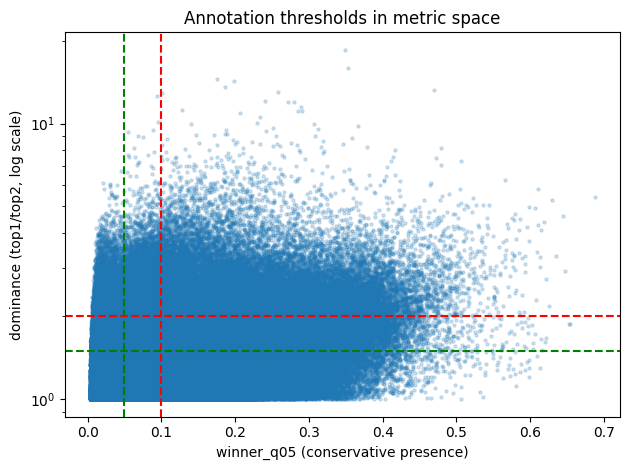

In [57]:
plt.figure()
plt.scatter(winner_q05, dom, s=5, alpha=0.2)
plt.axvline(0.05, linestyle="--", color = "green")
plt.axvline(0.10, linestyle="--", color = "red")
plt.axhline(1.5, linestyle="--", color = "green")
plt.axhline(2.0, linestyle="--", color = "red")
plt.yscale("log")
plt.xlabel("winner_q05 (conservative presence)")
plt.ylabel("dominance (top1/top2, log scale)")
plt.title("Annotation thresholds in metric space")
plt.tight_layout()
plt.show()


In [33]:
perm_mask = (winner_q05 >= 0.05) & (dom >= 1.5)
strict_mask = (winner_q05 >= 0.10) & (dom >= 2.0) & (sep >= 0.0)

print("Permissive pass fraction:", perm_mask.mean())
print("Strict pass fraction:", strict_mask.mean())
print("sep>=0 fraction:", (sep >= 0.0).mean())


Permissive pass fraction: 0.18556457350408148
Strict pass fraction: 0.04222365760503258
sep>=0 fraction: 0.06602448887890362


In [34]:
import pandas as pd

ann["perm_pass"] = perm_mask
ann["strict_pass"] = strict_mask

summary = ann.groupby("winner_celltype")[["perm_pass","strict_pass"]].mean().sort_values("perm_pass", ascending=False)
print(summary)


                 perm_pass  strict_pass
winner_celltype                        
Erythrocyte       0.388927     0.145152
Macrophage        0.230358     0.049101
Endothelial       0.220239     0.075292
Neutrophils       0.153062     0.018426
CAR_T_cell        0.124371     0.005669
Fibroblast        0.120978     0.006918
Monocyte          0.111045     0.009361
NK_cell           0.094364     0.015450
DC                0.021429     0.005357
B_cell            0.006021     0.000000
T_cell            0.001816     0.000259
B/T_cell          0.000000     0.000000


In [35]:
import pandas as pd

ann["perm_pass"] = perm_mask
ann["strict_pass"] = strict_mask

summary = ann.groupby("winner_celltype")[["perm_pass","strict_pass"]].mean().sort_values("perm_pass", ascending=False)
print(summary)


                 perm_pass  strict_pass
winner_celltype                        
Erythrocyte       0.388927     0.145152
Macrophage        0.230358     0.049101
Endothelial       0.220239     0.075292
Neutrophils       0.153062     0.018426
CAR_T_cell        0.124371     0.005669
Fibroblast        0.120978     0.006918
Monocyte          0.111045     0.009361
NK_cell           0.094364     0.015450
DC                0.021429     0.005357
B_cell            0.006021     0.000000
T_cell            0.001816     0.000259
B/T_cell          0.000000     0.000000


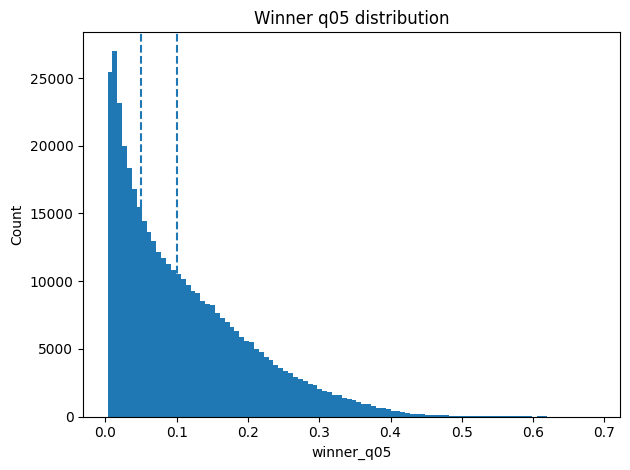

In [58]:
out_dir = "c2l_threshold_figures"
import os
os.makedirs(out_dir, exist_ok=True)

# rerun plots, but save instead of show
plt.figure()
plt.hist(winner_q05[np.isfinite(winner_q05)], bins=100)
plt.axvline(0.05, linestyle="--")
plt.axvline(0.10, linestyle="--")
plt.title("Winner q05 distribution")
plt.xlabel("winner_q05")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{out_dir}/winner_q05_hist.png", dpi=300)
plt.show()
plt.close()


# Quick validation

In [75]:
# Preserving the Raw counts
adata_vis.raw = adata_vis.copy()
sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)

In [76]:
group_key = "c2l_label_perm" # or "c2l_label_strict"
# exclude unknowns:
adata_markers = adata_vis[
    ~adata_vis.obs[group_key].isin(["Unknown", "B/T_cell"])
].copy()

In [77]:
adata_markers.obs["c2l_label_perm"].value_counts()

c2l_label_perm
Erythrocyte    38190
Fibroblast     16649
CAR_T_cell     14852
Neutrophils    12933
Macrophage      7977
NK_cell         5824
Endothelial     4047
Monocyte        3439
B_cell            66
T_cell            24
DC                18
Name: count, dtype: int64

In [78]:
import scanpy as sc

sc.tl.rank_genes_groups(
    adata_markers,
    groupby=group_key,
    method="wilcoxon",
    use_raw=False,        # X already contains raw counts
    n_genes=50            # compute more than 20, we’ll filter later
)


In [80]:
import numpy as np
import pandas as pd

def top_markers_per_group(
    adata,
    group_key: str,
    symbol_col: str = "SYMBOL",
    n_top: int = 20,
    uns_key: str = "rank_genes_groups",
):
    rg = adata.uns[uns_key]
    groups = rg["names"].dtype.names  # group names

    has_logfc = "logfoldchanges" in rg.keys()
    has_pts = "pts" in rg.keys()
    has_pts_rest = "pts_rest" in rg.keys()

    rows = []
    for g in groups:
        names = rg["names"][g][:n_top]
        scores = rg["scores"][g][:n_top]
        pvals_adj = rg["pvals_adj"][g][:n_top]

        if has_logfc:
            logfc = rg["logfoldchanges"][g][:n_top]
        else:
            logfc = np.full(len(names), np.nan)

        # Map Ensembl -> SYMBOL (handle missing gracefully)
        sym = adata.var.reindex(names)[symbol_col].to_numpy()
        sym = np.where(pd.isna(sym), names, sym)  # fallback to Ensembl if missing

        row = {
            "cell_type": [g] * len(names),
            "rank": np.arange(1, len(names) + 1),
            "ensembl_id": names,
            "symbol": sym,
            "score": scores,
            "logFC": logfc,
            "pval_adj": pvals_adj,
        }

        if has_pts:
            row["pct_in_group"] = rg["pts"][g][:n_top]
        if has_pts_rest:
            row["pct_out_group"] = rg["pts_rest"][g][:n_top]

        rows.append(pd.DataFrame(row))

    out = pd.concat(rows, ignore_index=True)
    return out


In [93]:
markers_df = top_markers_per_group(
    adata_markers,
    group_key=group_key,
    symbol_col="SYMBOL",
    n_top=50,
)

In [94]:
markers_df['cell_type'].unique()

array(['B_cell', 'CAR_T_cell', 'DC', 'Endothelial', 'Erythrocyte',
       'Fibroblast', 'Macrophage', 'Monocyte', 'NK_cell', 'Neutrophils',
       'T_cell'], dtype=object)

In [95]:
for cells in markers_df['cell_type'].unique():
    print(f"Cell Type: {cells}")
    print(markers_df[markers_df['cell_type'] == cells]['symbol'])

Cell Type: B_cell
0         Hras
1         Mdm2
2        Dusp4
3          Tes
4         Wsb1
5       Slc2a1
6         Ier3
7        Cpsf6
8         Gnl3
9        Ero1l
10       Nop56
11     Irf2bp2
12     Mybbp1a
13       Ddit4
14       Vegfa
15       Gpnmb
16       Egln3
17       Plin2
18     Slc27a1
19     Igf2bp2
20       Rap1b
21       Pgam1
22        Frs2
23     Bhlhe40
24      Arglu1
25         Ssb
26        Pcm1
27      Rbfox2
28        Xpo1
29      Prpf39
30         Pkm
31        H1f0
32         Mt1
33       Ddx17
34      Pabpc1
35        Ctsl
36    Atp6v1c1
37       Ndrg1
38        Mxi1
39      Ctnnb1
40        Tcim
41        Clk1
42        Stam
43       Fmnl2
44      Hilpda
45       Alcam
46       Trpm7
47        Cct2
48        Vars
49       Cand1
Name: symbol, dtype: object
Cell Type: CAR_T_cell
50      S100a4
51         Vim
52      S100a6
53        Txn1
54      Tmsb4x
55       Actg1
56      Tagln2
57         Clu
58       Fscn1
59      Tuba1a
60     S100a10
61        Ptms
62

## Visualizing

In [120]:
import scanpy as sc

group_key = "c2l_label_perm"  # or "c2l_label_strict"

adata_plot = adata_vis.copy()

adata_plot.var = (
    adata_plot.var
    .reset_index()                      # Ensembl IDs become a column
    .rename(columns={"index": "ensembl_id"})
    .set_index("SYMBOL")                # SYMBOL becomes the index
)

sc.pp.normalize_total(adata_plot, target_sum=1e4)
sc.pp.log1p(adata_plot)

In [132]:
marker_panel_from_top50 = {
    "B_cell":        ["Dusp4","Ier3","Irf2bp2","Bhlhe40","Rap1b","Tes"],
    "CAR_T_cell":    ["Ccl5","Tagln2","S100a4","Fscn1","Spp1","Vim"],   # interpret cautiously (you noted possible mislabel)
    "DC":            ["H2-Aa","H2-Ab1","Cd74","H2-Eb1","Ccl17","Mgl2"],
    "Endothelial":   ["Pecam1","Cdh5","Kdr","Flt1","Egfl7","Esam"],
    "Erythrocyte":   ["Col1a1","Col1a2","Col3a1","Postn","Dcn","Sparc"],  # this screams stromal/ECM, not RBC
    "Fibroblast":    ["Fn1","Nt5e","Serpinf1","Ibsp","Areg","Plau"],
    "Macrophage":    ["Apoe","Lyz2","C1qa","C1qb","Tyrobp","Ctss"],
    "Monocyte":      ["Isg15","Cxcl10","Cxcl9","Stat1","Plac8","Fcgr1"],
    "NK_cell":       ["Gzmb","Prf1","Il2rb","Id2","Gzmc","Gzmd"],
    "Neutrophils":   ["Il1b","Cebpb","Ptgs2","Srgn","Lgals3","Mmp12"],
    "T_cell":        ["Arhgdia","Fam49b","Nt5e","Tmem173","Map2k3","Lrig1"],  # not canonical T markers, but “best available” from that list
}



In [129]:
adata_plot.raw is not None
adata_plot.var_names[:5]
adata_plot.raw.var_names[:5] if adata_plot.raw is not None else None

Index(['ENSMUSG00000000001', 'ENSMUSG00000000028', 'ENSMUSG00000000056',
       'ENSMUSG00000000058', 'ENSMUSG00000000078'],
      dtype='object', name='gene_id')

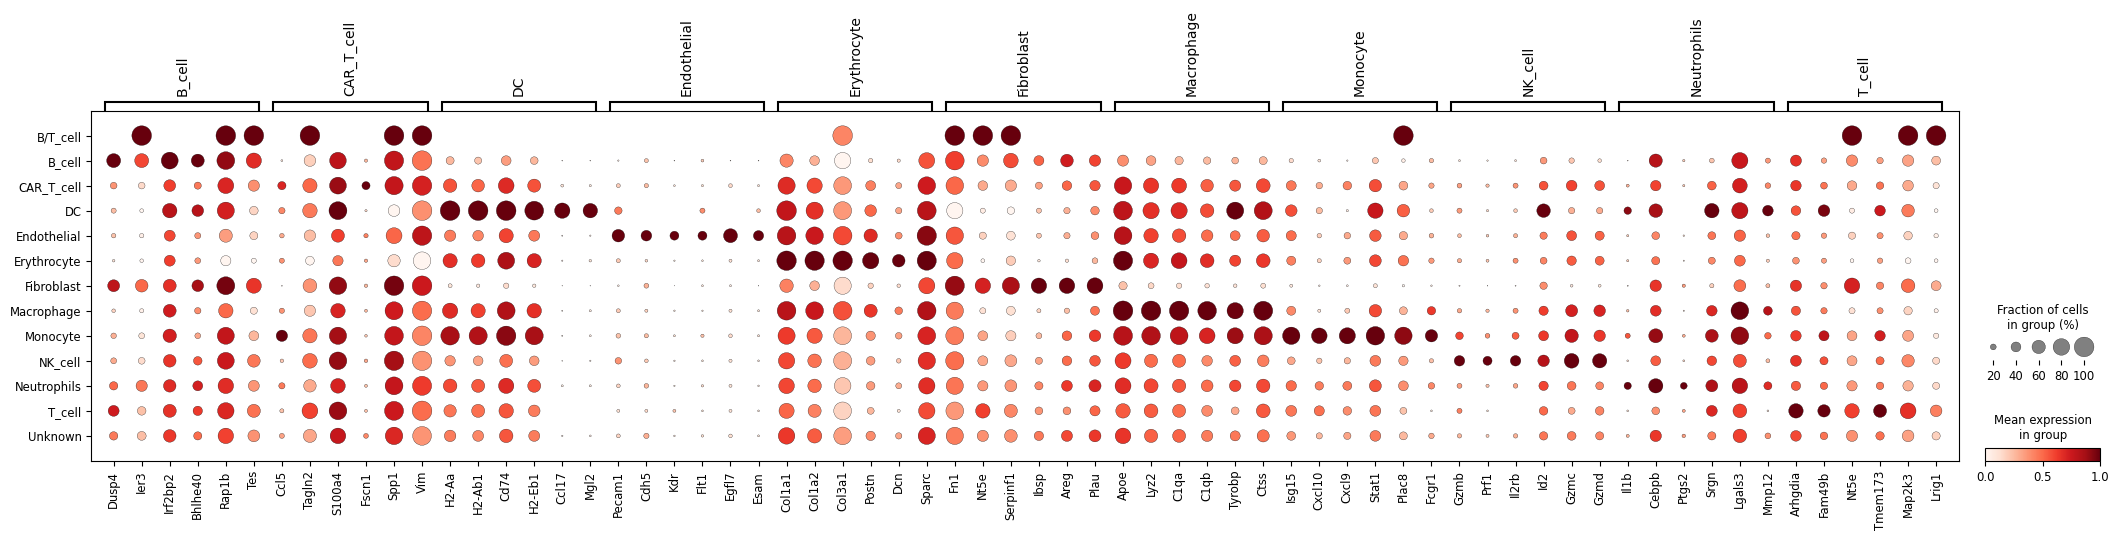

In [133]:
sc.pl.dotplot(
    adata_plot,
    marker_panel_from_top50,
    groupby="c2l_label_perm",
    # gene_symbols="SYMBOL",  # <-- map symbols to var_names
    use_raw=False,          # <-- optional but avoids raw mismatch
    standard_scale="var",
)


## Barplot, counts

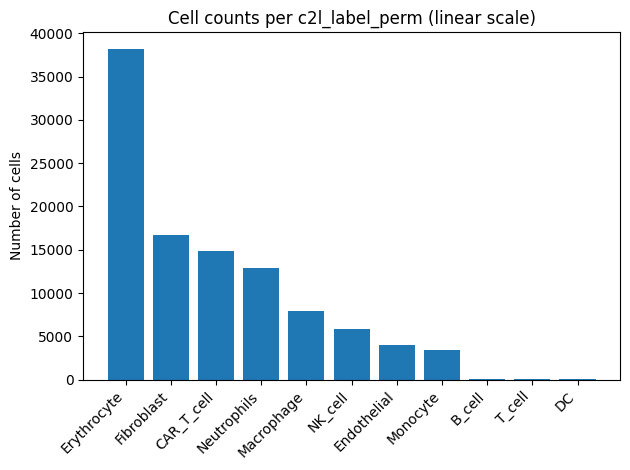

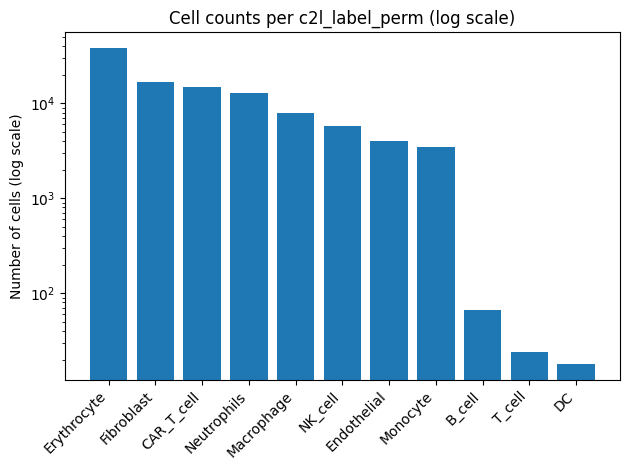

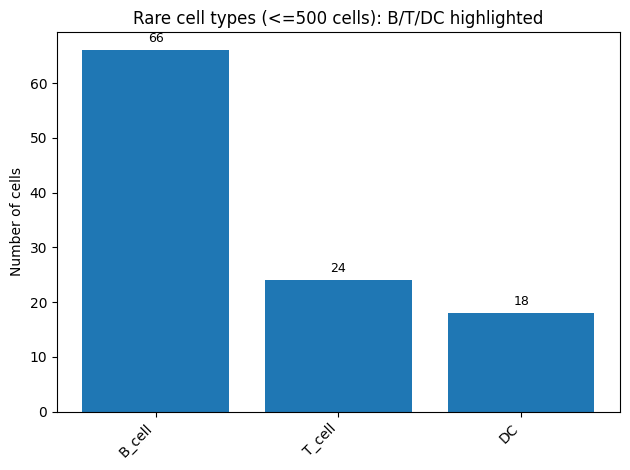

,count,percent
c2l_label_perm,,
Erythrocyte,38190,36.714446
Fibroblast,16649,16.005730
CAR_T_cell,14852,14.278161
Neutrophils,12933,12.433305
Macrophage,7977,7.668791
NK_cell,5824,5.598977
Endothelial,4047,3.890635
Monocyte,3439,3.306127
B_cell,66,0.063450


In [134]:
import matplotlib.pyplot as plt
import pandas as pd

group_key = "c2l_label_perm"
counts = adata_markers.obs[group_key].value_counts()

# 1) Linear scale
plt.figure()
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of cells")
plt.title(f"Cell counts per {group_key} (linear scale)")
plt.tight_layout()
plt.show()

# 2) Log scale (best for showing rare groups)
plt.figure()
plt.bar(counts.index, counts.values)
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of cells (log scale)")
plt.title(f"Cell counts per {group_key} (log scale)")
plt.tight_layout()
plt.show()

# 3) Zoomed-in rare populations only
rare = counts[counts <= 500]  # adjust threshold if you want (e.g., 1000)
plt.figure()
plt.bar(rare.index, rare.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of cells")
plt.title("Rare cell types (<=500 cells): B/T/DC highlighted")
for i, v in enumerate(rare.values):
    plt.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Optional: percent table to paste into slides/email
summary = pd.DataFrame({"count": counts})
summary["percent"] = 100 * summary["count"] / summary["count"].sum()
summary


# transfering labels to original adata file

In [135]:
import spatialdata as spd

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [136]:
# zarr_file = "/home/janzules/spatial/CAR-T/data/cell2location/adata/zarrFiles/CART_centroid"
# zdata = spd.read_zarr(zarr_file)

/tmp/ipykernel_1572653/2843293580.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  zdata = spd.read_zarr(zarr_file)


In [139]:
zdata.tables

{'segmentation_counts': AnnData object with n_obs × n_vars = 427296 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'}

In [138]:
adata_vis

AnnData object with n_obs × n_vars = 427296 × 12128
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'treatment', 'batch_core', 'mt_counts', '_indices', '_scvi_batch', '_scvi_labels', 'total RNA counts', 'c2l_label_perm', 'c2l_label_strict'
    var: 'SYMBOL'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod', 'spatialdata_attrs', 'log1p'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q50_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

In [140]:
import numpy as np
import pandas as pd
import spatialdata as spd

zarr_file = "/home/janzules/spatial/CAR-T/data/cell2location/adata/zarrFiles/CART_centroid"
zdata = spd.read_zarr(zarr_file)

# Grab the original AnnData inside the SpatialData object
z_adata = zdata.tables["segmentation_counts"]

print("adata_vis:", adata_vis.shape)
print("z_adata  :", z_adata.shape)

/tmp/ipykernel_1572653/2985750747.py:6: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  zdata = spd.read_zarr(zarr_file)


adata_vis: (427296, 12128)
z_adata  : (427296, 19059)


In [141]:
# -----------------------------
# 1) Decide what to transfer
# -----------------------------
# Recommended: transfer any new columns you created (anything present in adata_vis but not in z_adata)
new_cols = adata_vis.obs.columns.difference(z_adata.obs.columns).tolist()

# Also force-transfer your main annotation columns (even if they already exist)
force_cols = [c for c in ["c2l_label_perm", "c2l_label_strict"] if c in adata_vis.obs.columns]

# You can add other columns you care about explicitly here:
# e.g., force_cols += ["c2l_label_strict_clean", "purity", "winner_q05", ...]
cols_to_transfer = sorted(set(new_cols + force_cols))

print(f"New cols in adata_vis not in z_adata: {len(new_cols)}")
print(f"Total cols_to_transfer: {len(cols_to_transfer)}")
print(cols_to_transfer[:25], "..." if len(cols_to_transfer) > 25 else "")

New cols in adata_vis not in z_adata: 9
Total cols_to_transfer: 9
['_indices', '_scvi_batch', '_scvi_labels', 'batch_core', 'c2l_label_perm', 'c2l_label_strict', 'mt_counts', 'total RNA counts', 'treatment'] 


In [142]:
assert adata_vis.n_obs == z_adata.n_obs, "n_obs differs — cannot do 1:1 transfer safely."

In [145]:
adata_vis.obs_names.equals(z_adata.obs_names)

True

In [146]:
if len(cols_to_transfer) == 0:
    print("Nothing new to transfer (adata_vis.obs has no extra columns vs z_adata.obs).")
else:
    # -----------------------------
    # 2) Sanity checks on index
    # -----------------------------
    # Quick checks
    assert adata_vis.n_obs == z_adata.n_obs, "n_obs differs — cannot do 1:1 transfer safely."

    same_names = adata_vis.obs_names.equals(z_adata.obs_names)
    # ✔ Every single barcode matches
    # ✔ Order is identical
    # ✔ Row-wise assignment is exact
    # ✔ No reindexing, joins, or heuristics involved
    # ✔ Zero risk of annotation drift
    
    same_set = set(adata_vis.obs_names) == set(z_adata.obs_names)

    print("Same obs_names AND same order:", same_names)
    print("Same obs_names set (order may differ):", same_set)

    if not same_set:
        # Fallback to joining on stable keys if needed
        # (only run if you ever hit this case)
        raise RuntimeError(
            "obs_names sets differ. If you truly expect same cells, join using a key "
            "like ['sample','cell_id'] or another unique identifier."
        )

    # -----------------------------
    # 3) Transfer
    # -----------------------------
    if same_names:
        # Fast path: exact alignment
        z_adata.obs.loc[:, cols_to_transfer] = adata_vis.obs[cols_to_transfer].to_numpy()
    else:
        # Safe path: reindex adata_vis to z_adata order
        aligned = adata_vis.obs.loc[z_adata.obs_names, cols_to_transfer]
        z_adata.obs.loc[:, cols_to_transfer] = aligned.to_numpy()

    # -----------------------------
    # 4) Post-transfer sanity checks
    # -----------------------------
    # Check random rows across transferred columns
    rng = np.random.default_rng(0)
    idx = rng.choice(z_adata.n_obs, size=20, replace=False)
    check_names = z_adata.obs_names[idx]

    left = z_adata.obs.loc[check_names, cols_to_transfer]
    right = adata_vis.obs.loc[check_names, cols_to_transfer]

    # For robust compare across dtypes
    mism = (left.astype(str) != right.astype(str)).to_numpy().sum()
    print(f"Random-sample mismatches across transferred fields: {mism}")

    # Full-column equality rates (string compare avoids categorical quirks)
    eq_rates = {}
    for c in cols_to_transfer:
        eq = (z_adata.obs[c].astype(str).values == adata_vis.obs.loc[z_adata.obs_names, c].astype(str).values).mean()
        eq_rates[c] = eq
    worst = sorted(eq_rates.items(), key=lambda x: x[1])[:10]
    print("Worst 10 equality rates:", worst)

    assert all(v == 1.0 for v in eq_rates.values()), "Some transferred columns do not match perfectly!"

Same obs_names AND same order: True
Same obs_names set (order may differ): True
Random-sample mismatches across transferred fields: 0
Worst 10 equality rates: [('_indices', np.float64(1.0)), ('_scvi_batch', np.float64(1.0)), ('_scvi_labels', np.float64(1.0)), ('batch_core', np.float64(1.0)), ('c2l_label_perm', np.float64(1.0)), ('c2l_label_strict', np.float64(1.0)), ('mt_counts', np.float64(1.0)), ('total RNA counts', np.float64(1.0)), ('treatment', np.float64(1.0))]


In [ ]:
# -----------------------------
# 5) (Optional) transfer .uns keys you added
# -----------------------------
z_adata.uns["cell2location_provenance"] = {
    "model_name": adata_vis.uns["mod"].get("model_name"),
    "date": adata_vis.uns["mod"].get("date"),
    "factor_names": list(adata_vis.uns["mod"].get("factor_names", [])),
    "n_cells": adata_vis.n_obs,
    "gene_universe_size": adata_vis.n_vars,
    "scvi_uuid": adata_vis.uns.get("_scvi_uuid"),
    "scvi_manager_uuid": adata_vis.uns.get("_scvi_manager_uuid"),
    "log1p": adata_vis.uns.get("log1p"),
}

In [172]:
z_adata.obs = z_adata.obs.rename(columns={"total RNA counts": "total_RNA_counts"})

# Now this will pass validation
zdata.tables["segmentation_counts"] = z_adata

In [173]:
zdata.tables["segmentation_counts"]

AnnData object with n_obs × n_vars = 427296 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', '_indices', '_scvi_batch', '_scvi_labels', 'batch_core', 'c2l_label_perm', 'c2l_label_strict', 'mt_counts', 'total_RNA_counts', 'treatment'
    uns: 'spatialdata_attrs', 'cell2location_provenance'
    obsm: 'spatial'

## Saving

In [179]:
# -----------------------------
# 6) Save back to Zarr
# -----------------------------
# Strongly recommended: write to a NEW path first, then swap if you’re happy.
out_zarr = zarr_file + "_with_annotations"

zdata.write(out_zarr, overwrite=True)

print("Wrote updated SpatialData to:", out_zarr)

# If you truly want to overwrite the original Zarr (risky), uncomment:
# spd.write_zarr(zdata, zarr_file, overwrite=True)
# print("Overwrote original Zarr at:", zarr_file)

Wrote updated SpatialData to: /home/janzules/spatial/CAR-T/data/cell2location/adata/zarrFiles/CART_centroid_with_annotations


# qc stuff

In [14]:
import re
import numpy as np
import pandas as pd

def normalize_celltype_cols(df: pd.DataFrame) -> pd.DataFrame:
    # keep everything after "_sf_" (works for your shown column patterns)
    new_cols = [re.sub(r"^.*?_sf_", "", c) for c in df.columns]
    out = df.copy()
    out.columns = new_cols
    return out

means_df = normalize_celltype_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
q05_df   = normalize_celltype_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])
q95_df   = normalize_celltype_cols(adata_vis.obsm["q95_cell_abundance_w_sf"])

# align columns to common set + same order
common = sorted(set(means_df.columns) & set(q05_df.columns) & set(q95_df.columns))
means_df = means_df[common]
q05_df   = q05_df[common]
q95_df   = q95_df[common]

assert (means_df.columns == q05_df.columns).all()
assert (means_df.columns == q95_df.columns).all()


In [36]:
q95_df['Macrophage'].describe()

count    427296.000000
mean          0.145091
std           0.083652
min           0.038473
25%           0.080792
50%           0.120248
75%           0.189371
max           0.823512
Name: Macrophage, dtype: float64

In [30]:
print(means_df.columns)
print(q05_df.columns)
print(q95_df.columns)


Index(['B/T_cell', 'B_cell', 'CAR_T_cell', 'DC', 'Endothelial', 'Erythrocyte',
       'Fibroblast', 'Macrophage', 'Monocyte', 'NK_cell', 'Neutrophils',
       'T_cell'],
      dtype='object')
Index(['B/T_cell', 'B_cell', 'CAR_T_cell', 'DC', 'Endothelial', 'Erythrocyte',
       'Fibroblast', 'Macrophage', 'Monocyte', 'NK_cell', 'Neutrophils',
       'T_cell'],
      dtype='object')
Index(['B/T_cell', 'B_cell', 'CAR_T_cell', 'DC', 'Endothelial', 'Erythrocyte',
       'Fibroblast', 'Macrophage', 'Monocyte', 'NK_cell', 'Neutrophils',
       'T_cell'],
      dtype='object')


In [15]:
total_abundance = means_df.sum(axis=1).to_numpy()
qs = np.quantile(total_abundance, [0.5, 0.9, 0.95, 0.99, 0.999])
print("total_abundance quantiles:", dict(zip([0.5,0.9,0.95,0.99,0.999], qs)))
print("max:", total_abundance.max())


total_abundance quantiles: {0.5: np.float64(1.4153266549110413), 0.9: np.float64(2.516178250312805), 0.95: np.float64(2.8623655438423157), 0.99: np.float64(3.621589362621303), 0.999: np.float64(4.640334224700942)}
max: 6.917683


N_cells_per_location ≈ 1.5.

Median total abundance 
≈
1.42
≈1.42 — close to your prior.

90–95% are 
≈
2.5
–
2.9
≈2.5–2.9 — plausible for occasional merged/over-segmented objects, doublets, or bins that capture extra RNA.

99–99.9% 
≈
3.6
–
4.6
≈3.6–4.6 — still plausible tail.

Max 6.9 is an outlier, not the typical scale-driver.

# Visualizing Dominance

## tOdO

* I need to add a legend to the q05 of the winner and q95 of the runner up

In [6]:
import numpy as np
from scipy.stats import lognorm

def fit_lognorm_from_q05_q95(q05, q95, eps=1e-6):
    """
    Fit an approximate log-normal distribution using q05 and q95.
    Returns scipy.stats.lognorm distribution object.
    """
    q05 = max(float(q05), eps)
    q95 = max(float(q95), q05 + eps)

    z05 = -1.6448536269514722
    z95 =  1.6448536269514722

    sigma = (np.log(q95) - np.log(q05)) / (z95 - z05)
    mu = np.log(q05) - sigma * z05

    # scipy parameterization: lognorm(s=sigma, scale=exp(mu))
    dist = lognorm(s=sigma, scale=np.exp(mu))
    return dist, mu, sigma

In [7]:
import numpy as np
import pandas as pd

# assuming you already have:
# means_df, q05_df, q95_df

M = means_df.to_numpy()
Q05 = q05_df.to_numpy()
Q95 = q95_df.to_numpy()

celltypes = means_df.columns.to_numpy()
n, k = M.shape

# winner by mean
win_idx = M.argmax(axis=1)
win_mean = M[np.arange(n), win_idx]
win_q05  = Q05[np.arange(n), win_idx]
win_q95  = Q95[np.arange(n), win_idx]

# runner-up by mean
top2_idx = np.argpartition(M, -2, axis=1)[:, -2:]
ru_idx = np.where(top2_idx[:, 0] == win_idx, top2_idx[:, 1], top2_idx[:, 0])

ru_mean = M[np.arange(n), ru_idx]
ru_q05  = Q05[np.arange(n), ru_idx]
ru_q95  = Q95[np.arange(n), ru_idx]

# summary scores
dom_mean = win_mean / (ru_mean + 1e-12)
dom_cons = win_q05 / (ru_q95 + 1e-12)
sep = win_q05 - ru_q95

summary_df = pd.DataFrame({
    "winner_celltype": celltypes[win_idx],
    "winner_mean": win_mean,
    "winner_q05": win_q05,
    "winner_q95": win_q95,
    "runnerup_celltype": celltypes[ru_idx],
    "runnerup_mean": ru_mean,
    "runnerup_q05": ru_q05,
    "runnerup_q95": ru_q95,
    "dom_mean": dom_mean,
    "dom_cons": dom_cons,
    "sep": sep,
}, index=means_df.index)

summary_df.head()

,winner_celltype,winner_mean,winner_q05,winner_q95,runnerup_celltype,runnerup_mean,runnerup_q05,runnerup_q95,dom_mean,dom_cons,sep
F07839_1n2_OME_cellid_000000001-1,Classical_Mono,0.186772,0.087927,0.343700,Erythrocyte,0.108783,0.008377,0.300631,1.716919,0.292476,-0.212704
F07839_1n2_OME_cellid_000000002-1,N1_like_Neu,0.263695,0.046045,0.678394,Erythrocyte,0.144067,0.009678,0.481165,1.830365,0.095694,-0.435121
F07839_1n2_OME_cellid_000000004-1,N1_like_Neu,0.160050,0.015599,0.539605,N2_like_Neu,0.056946,0.003562,0.167501,2.810550,0.093131,-0.151901
F07839_1n2_OME_cellid_000000005-1,N2_like_Neu,0.181347,0.027138,0.539144,N1_like_Neu,0.143406,0.012661,0.456464,1.264573,0.059452,-0.429327
F07839_1n2_OME_cellid_000000006-1,N2_like_Neu,0.131252,0.003303,0.481048,N1_like_Neu,0.097730,0.011336,0.302300,1.343008,0.010928,-0.298996


In [65]:
summary_df.head()

,winner_celltype,winner_mean,winner_q05,winner_q95,runnerup_celltype,runnerup_mean,runnerup_q05,runnerup_q95,dom_mean,dom_cons,sep
F07839_cellid_000000001-1,NK,0.144853,0.110801,0.188623,CD8_T,0.135502,0.088996,0.202598,1.069010,0.546901,-0.091797
F07839_cellid_000000002-1,CD8_T,0.296309,0.216500,0.390534,NK,0.199984,0.155584,0.251822,1.481668,0.859731,-0.035323
F07839_cellid_000000004-1,Classical_Mono,0.109644,0.065522,0.176132,M1_like_Mac,0.101809,0.064515,0.152886,1.076958,0.428570,-0.087363
F07839_cellid_000000005-1,Classical_Mono,0.233510,0.164981,0.311602,CD8_T,0.163069,0.115328,0.220256,1.431966,0.749045,-0.055274
F07839_cellid_000000006-1,Classical_Mono,0.193740,0.123244,0.272196,Nonclassical_Mono,0.176731,0.119476,0.241504,1.096241,0.510321,-0.118259


In [8]:
# Example 1: mean dominance > 1.5, but conservative dominance < 1
example_mean_only = summary_df[
    # (summary_df["sep"] >= 0)
    (summary_df["dom_mean"] >= 1.1) &
    # (summary_df["dom_mean"] <= 1.6) &
    (summary_df["dom_cons"] >= 0.15) #&
    # (summary_df["dom_cons"] <= 0.4)
].sort_values("dom_mean", ascending=False)

# print("Mean-dominant but not conservative:")
# display(example_mean_only.head(5))


total = len(summary_df)
passed = (
    # (summary_df["sep"] >= 0)
    (summary_df["dom_mean"] >= 1.1) &
    # (summary_df["dom_mean"] <= 1.6) &
    (summary_df["dom_cons"] >= 0.05) #&
    # (summary_df["dom_cons"] <= 0.4)
).sum()

print(f"Pass: {passed / total * 100:.1f}%  |  Fail: {(total - passed) / total * 100:.1f}%  ({passed}/{total})")


Pass: 58.8%  |  Fail: 41.2%  (1227720/2088557)


In [80]:

# # Example 2: conservative dominance > 1.5
# example_conservative = summary_df[
#     (summary_df["dom_cons"] > 1.5)
# ].sort_values("dom_cons", ascending=False)

# print("Conservatively dominant:")
# display(example_conservative.head(5))

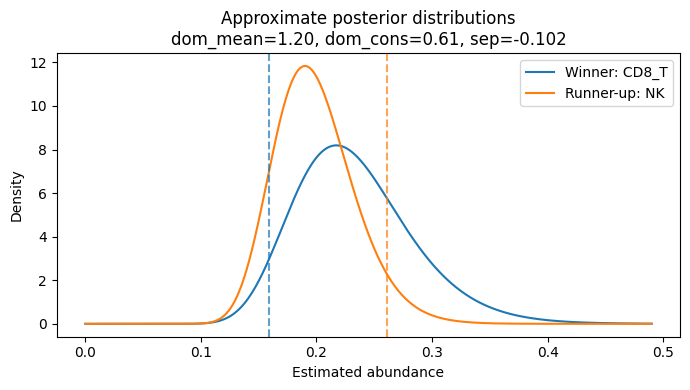

winner_celltype         CD8_T
winner_mean          0.236659
winner_q05           0.158924
winner_q95           0.326607
runnerup_celltype          NK
runnerup_mean        0.197216
runnerup_q05         0.147006
runnerup_q95          0.26118
dom_mean             1.200001
dom_cons             0.608484
sep                 -0.102256
Name: F07840_cellid_000056106-1, dtype: object


In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Pick one row from one of the example tables
# row_id = example_conservative.index[6000]   # or example_mean_only.index[0]
row_id = example_mean_only.index[-1]
# row_id = example_mean_only.index[3* len(example_mean_only) // 4]
# row_id = example_mean_only.index[len(example_mean_only) // 2]


row = summary_df.loc[row_id]

# Fit approximate posteriors
dist_win, mu_w, sig_w = fit_lognorm_from_q05_q95(row["winner_q05"], row["winner_q95"])
dist_ru,  mu_r, sig_r = fit_lognorm_from_q05_q95(row["runnerup_q05"], row["runnerup_q95"])

# x-range
xmax = max(row["winner_q95"], row["runnerup_q95"]) * 1.5
x = np.linspace(1e-5, xmax, 500)

# densities
y_win = dist_win.pdf(x)
y_ru  = dist_ru.pdf(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_win, label=f"Winner: {row['winner_celltype']}")
ax.plot(x, y_ru,  label=f"Runner-up: {row['runnerup_celltype']}")

# vertical lines for q05/q95
ax.axvline(row["winner_q05"], linestyle="--", alpha=0.7)
ax.axvline(row["runnerup_q95"], linestyle="--", alpha=0.7, color='C1')

ax.set_title(
    f"Approximate posterior distributions\n"
    f"dom_mean={row['dom_mean']:.2f}, dom_cons={row['dom_cons']:.2f}, sep={row['sep']:.3f}"
)
ax.set_xlabel("Estimated abundance")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print(row)

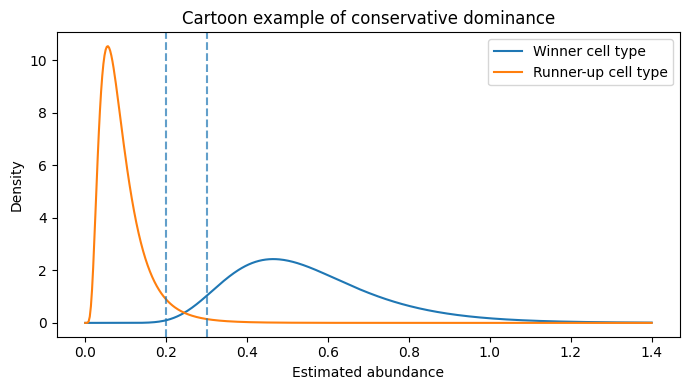

Conservative dominance = 1.4999999999999998


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Cartoon example:
# winner lower bound is 1.5x runner-up upper bound
winner_q05 = 0.30
winner_q95 = 0.90

runner_q05 = 0.03
runner_q95 = 0.20

dist_win, _, _ = fit_lognorm_from_q05_q95(winner_q05, winner_q95)
dist_ru,  _, _ = fit_lognorm_from_q05_q95(runner_q05, runner_q95)

x = np.linspace(1e-4, 1.4, 500)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x, dist_win.pdf(x), label="Winner cell type")
ax.plot(x, dist_ru.pdf(x), label="Runner-up cell type")

ax.axvline(winner_q05, linestyle="--", alpha=0.7)
ax.axvline(runner_q95, linestyle="--", alpha=0.7)

ax.set_title("Cartoon example of conservative dominance")
ax.set_xlabel("Estimated abundance")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print("Conservative dominance =", winner_q05 / runner_q95)

## Visualizing multiple distributions

Pick one random cell from each quartile of `dom_mean` (after the same selection
filter as Example 1), and plot the approximate posterior distributions of the
top N cell types in that cell. `dom_mean`, `dom_cons`, and `sep` shown in each
panel are computed only between the winner and the runner-up.

TODO:
* sort by dom_cons instead of mean.

43

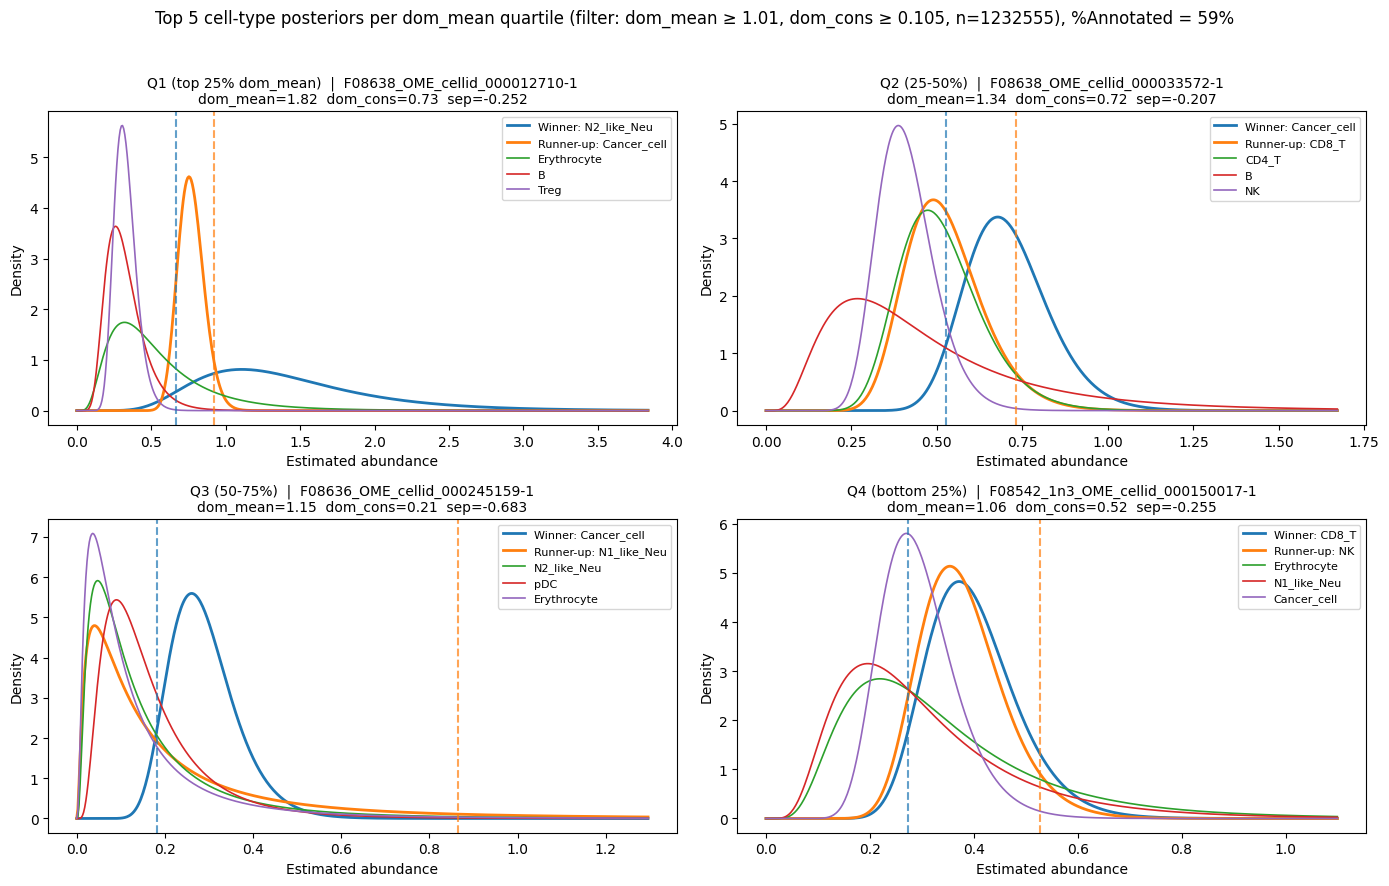

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ---- knobs ----
DOM_MEAN_MIN = 1.01
DOM_CONS_MIN = 0.105

# DOM_MEAN_MIN = 1.2
# DOM_CONS_MIN = 0.2

N_TOP_CELLTYPES = 5      # how many cell-type distributions to plot per panel (>= 2)
RANDOM_SEED    = None #1

# ---- selection (same logic as Example 1) ----
sel_mask = (
    (summary_df["dom_mean"] >= DOM_MEAN_MIN) &
    (summary_df["dom_cons"] >= DOM_CONS_MIN)
)
selected = summary_df[sel_mask].sort_values("dom_mean", ascending=False)
n_sel = len(selected)
assert n_sel >= 4, f"Only {n_sel} cells passed the filter; need at least 4 for quartile sampling."

# quartile edges by rank position (descending dom_mean)
edges = np.linspace(0, n_sel, 5, dtype=int)   # [0, n/4, n/2, 3n/4, n]
quartile_ranges = [(edges[i], edges[i+1]) for i in range(4)]
quartile_labels = [
    "Q1 (top 25% dom_mean)",
    "Q2 (25-50%)",
    "Q3 (50-75%)",
    "Q4 (bottom 25%)",
]

rng = np.random.default_rng(RANDOM_SEED)
picked_ids = [selected.index[rng.integers(lo, hi)] for lo, hi in quartile_ranges]


def plot_cell_distributions(ax, row_id, n_top=N_TOP_CELLTYPES):
    means_row = means_df.loc[row_id]
    q05_row   = q05_df.loc[row_id]
    q95_row   = q95_df.loc[row_id]

    top_ct   = means_row.sort_values(ascending=False).head(n_top).index.tolist()
    winner   = top_ct[0]
    runnerup = top_ct[1]

    xmax = max(q95_row[ct] for ct in top_ct) * 1.5
    x = np.linspace(1e-5, xmax, 500)

    for ct in top_ct:
        dist, _, _ = fit_lognorm_from_q05_q95(q05_row[ct], q95_row[ct])
        if ct == winner:
            label, lw = f"Winner: {ct}", 2.0
        elif ct == runnerup:
            label, lw = f"Runner-up: {ct}", 2.0
        else:
            label, lw = ct, 1.2
        ax.plot(x, dist.pdf(x), label=label, linewidth=lw)

    ax.axvline(q05_row[winner],   linestyle="--", alpha=0.7, color="C0")
    ax.axvline(q95_row[runnerup], linestyle="--", alpha=0.7, color="C1")

    win_mean = means_row[winner]
    ru_mean  = means_row[runnerup]
    win_q05  = q05_row[winner]
    ru_q95   = q95_row[runnerup]
    dom_mean_v = win_mean / (ru_mean + 1e-12)
    dom_cons_v = win_q05  / (ru_q95  + 1e-12)
    sep_v      = win_q05  - ru_q95

    ax.set_xlabel("Estimated abundance")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    return dom_mean_v, dom_cons_v, sep_v


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, row_id, qlabel in zip(axes.flatten(), picked_ids, quartile_labels):
    dom_m, dom_c, sep_v = plot_cell_distributions(ax, row_id)
    ax.set_title(
        f"{qlabel}  |  {row_id}\n"
        f"dom_mean={dom_m:.2f}  dom_cons={dom_c:.2f}  sep={sep_v:.3f}",
        fontsize=10,
    )

fig.suptitle(
    f"Top {N_TOP_CELLTYPES} cell-type posteriors per dom_mean quartile "
    f"(filter: dom_mean ≥ {DOM_MEAN_MIN}, dom_cons ≥ {DOM_CONS_MIN}, n={n_sel}), %Annotated = {round(len(selected)/len(summary_df) * 100)}%",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Annotation Testing

In [19]:
import numpy as np
import pandas as pd

def annotate_cell2location(
    means_df: pd.DataFrame,
    q05_df: pd.DataFrame,
    q95_df: pd.DataFrame,
    q_cut: float = 0.10,
    purity_cut: float = 0.60,
    sep_cut: float = 0.00,
    min_total_mean: float = 0.25,   # optional: ignore ultra-low total-abundance segments
    unknown_label: str = "Unknown",
):
    # Ensure alignment
    assert (means_df.columns == q05_df.columns).all()
    assert (means_df.columns == q95_df.columns).all()

    M = means_df.to_numpy()
    Q05 = q05_df.to_numpy()
    Q95 = q95_df.to_numpy()
    n, k = M.shape

    # Winner by mean
    win_idx = M.argmax(axis=1)
    win_mean = M[np.arange(n), win_idx]
    win_q05  = Q05[np.arange(n), win_idx]
    win_q95  = Q95[np.arange(n), win_idx]

    # Total abundance + purity
    total_mean = M.sum(axis=1)
    purity = np.divide(win_mean, total_mean, out=np.zeros_like(win_mean), where=total_mean>0)

    # Runner-up by mean (second largest)
    # argpartition gives unordered top2 indices; then pick runner-up
    top2_idx = np.argpartition(M, -2, axis=1)[:, -2:]  # shape (n,2)
    # determine runner-up index per row
    ru_idx = np.where(top2_idx[:,0] == win_idx, top2_idx[:,1], top2_idx[:,0])
    ru_q95 = Q95[np.arange(n), ru_idx]

    # Separation (uncertainty-aware)
    sep = win_q05 - ru_q95

    # High-confidence gate
    ok = (
        (total_mean >= min_total_mean) &
        (win_q05 >= q_cut) &
        (purity >= purity_cut) &
        (sep >= sep_cut)
    )

    celltypes = means_df.columns.to_numpy()
    labels = np.where(ok, celltypes[win_idx], unknown_label)

    out = pd.DataFrame({
        "label": labels,
        "winner_celltype": celltypes[win_idx],
        "winner_mean": win_mean,
        "winner_q05": win_q05,
        "winner_q95": win_q95,
        "runnerup_celltype": celltypes[ru_idx],
        "runnerup_q95": ru_q95,
        "sep_q05_minus_runnerup_q95": sep,
        "purity": purity,
        "total_abundance_mean": total_mean,
        "is_high_conf": ok,
    }, index=means_df.index)

    return out

ann = annotate_cell2location(means_df, q05_df, q95_df,
                            q_cut=0.10, purity_cut=0.60, sep_cut=0.00)

# adata_vis.obs["c2l_label_strict"] = ann["label"].astype(str).values


In [20]:
def calibrate_cutoffs(
    means_df, q05_df, q95_df,
    treatment: pd.Series,
    negative_condition: str = "NoTx",
    negative_celltype: str = "CAR_T_cell",
    q_cuts=(0.05, 0.10, 0.15, 0.20, 0.25),
    purity_cuts=(0.50, 0.60, 0.70, 0.80),
    sep_cuts=(0.00, 0.05, 0.10),
):
    rows = []
    for q_cut in q_cuts:
        for p_cut in purity_cuts:
            for s_cut in sep_cuts:
                ann = annotate_cell2location(means_df, q05_df, q95_df,
                                             q_cut=q_cut, purity_cut=p_cut, sep_cut=s_cut)
                # overall labeled fraction
                labeled_frac = (ann["label"] != "Unknown").mean()

                # false positives in negative condition
                neg_mask = (treatment.values == negative_condition)
                if neg_mask.sum() > 0:
                    neg_rate = (ann.loc[neg_mask, "label"] == negative_celltype).mean()
                else:
                    neg_rate = np.nan

                # simple score: penalize neg_rate heavily, prefer more labeled
                # tweak weights to your taste
                score = (labeled_frac * 1.0) - (neg_rate * 5.0 if not np.isnan(neg_rate) else 0.0)

                rows.append((q_cut, p_cut, s_cut, labeled_frac, neg_rate, score))

    res = pd.DataFrame(rows, columns=["q_cut","purity_cut","sep_cut",
                                      "labeled_frac","neg_rate_in_NoTx","score"])
    return res.sort_values("score", ascending=False)

# Example usage:
cal = calibrate_cutoffs(means_df, q05_df, q95_df,
                        treatment=adata_vis.obs["treatment"],
                        negative_condition="NoTx_Tu1",   # adjust to your exact label
                        negative_celltype="CAR_T_cell")
print(cal.head(15))


    q_cut  purity_cut  sep_cut  labeled_frac  neg_rate_in_NoTx     score
0    0.05         0.5     0.00      0.000686               0.0  0.000686
1    0.05         0.5     0.05      0.000686               0.0  0.000686
2    0.05         0.5     0.10      0.000686               0.0  0.000686
12   0.10         0.5     0.00      0.000686               0.0  0.000686
25   0.15         0.5     0.05      0.000686               0.0  0.000686
14   0.10         0.5     0.10      0.000686               0.0  0.000686
24   0.15         0.5     0.00      0.000686               0.0  0.000686
26   0.15         0.5     0.10      0.000686               0.0  0.000686
13   0.10         0.5     0.05      0.000686               0.0  0.000686
36   0.20         0.5     0.00      0.000686               0.0  0.000686
38   0.20         0.5     0.10      0.000686               0.0  0.000686
37   0.20         0.5     0.05      0.000686               0.0  0.000686
49   0.25         0.5     0.05      0.000686       

In [21]:
# A) Confirm how many cells are in your “NoTx_Tu1” mask
treat = adata_vis.obs["treatment"].astype(str)
print(treat.value_counts())
print("NoTx_Tu1 n =", (treat == "NoTx_Tu1").sum())

treatment
NoTx_Tu2         97293
RTCyTAG72_Tu2    86077
CyPSCA_Tu1       68486
RTCyPSCA_Tu2     47061
RTCyPSCA_Tu1     45436
CyTAG72_Tu1      31390
CyTAG72_Tu2      17859
CyPSCA_Tu2       16127
NoTx_Tu1         14820
RTCyTAG72_Tu1     2747
Name: count, dtype: int64
NoTx_Tu1 n = 14820


In [22]:
# B) Look at the distribution of the bottleneck metric (almost certainly sep)

# Run your annotator once with any settings, and inspect sep:

ann = annotate_cell2location(means_df, q05_df, q95_df,
                            q_cut=0.10, purity_cut=0.50, sep_cut=0.00)

print(ann["sep_q05_minus_runnerup_q95"].describe(percentiles=[0.5,0.9,0.95,0.99]))
print("fraction sep>0:", (ann["sep_q05_minus_runnerup_q95"] > 0).mean())
print("fraction sep>0.1:", (ann["sep_q05_minus_runnerup_q95"] > 0.1).mean())

count    427296.000000
mean         -0.092665
std           0.077199
min          -0.668232
50%          -0.086308
90%          -0.020314
95%           0.015224
99%           0.135220
max           0.666944
Name: sep_q05_minus_runnerup_q95, dtype: float64
fraction sep>0: 0.06602448887890362
fraction sep>0.1: 0.014991949374672358


In [23]:
# C) Check how labeling behaves if you temporarily remove the sep criterion

# This tells you whether the model can label “reasonably” under a more practical rule:

ann_no_sep = annotate_cell2location(means_df, q05_df, q95_df,
                                    q_cut=0.10, purity_cut=0.60, sep_cut=-np.inf)

print("labeled_frac (no sep):", (ann_no_sep["label"] != "Unknown").mean())
print("CAR_T in NoTx_Tu1 (no sep):",
      (ann_no_sep.loc[treat=="NoTx_Tu1", "label"] == "CAR_T_cell").mean())


labeled_frac (no sep): 1.1701490301804838e-05
CAR_T in NoTx_Tu1 (no sep): 0.0


## Identifying the bottleneck

This output is really informative — it tells us the “sep” rule is not the main reason you’re labeling almost nothing. The bottleneck is elsewhere (very likely your purity cutoff, and/or winner_q05 cutoff, or NaNs).

What I read from your screenshot

A) Your negative-control mask is fine

NoTx_Tu1 n = 14820 → you have plenty of NoTx cells to measure “false CAR-T calls.” Good.

B) Your separation metric has the behavior I’d expect
sep = winner_q05 - runnerup_q95:

median (50%) ≈ -0.086 → for most cells, the winner’s conservative lower bound is below the runner-up’s conservative upper bound (credible intervals overlap), which is normal in mixture models.

fraction sep > 0 ≈ 0.066 → about 6.6% of cells have a winner that is credibly separated from runner-up (at this strict definition).

fraction sep > 0.1 ≈ 0.015 → about 1.5% are strongly separated.

So sep isn’t “impossible.” There are plenty of positives.

C) But your labeling fraction is still basically zero
With sep_cut = -inf (i.e., sep removed), labeled_frac ≈ 1.17e-05 → 0.001% labeled. That screams:

the thing killing labels is one (or more) of: winner_q05 >= q_cut, purity >= purity_cut, or min_total_mean, not sep.

Also: CAR_T in NoTx_Tu1 (no sep) = 0.0 is not reassuring yet, because if you label ~0.001% of cells total, you can easily get 0 CAR-T just because almost nothing is labeled at all.

In [37]:
import numpy as np

ann = annotate_cell2location(means_df, q05_df, q95_df,
                            q_cut=0.10, purity_cut=0.60, sep_cut=-np.inf)

treat = adata_vis.obs["treatment"].astype(str).to_numpy()

# Gate pass rates
gate_total  = (ann["total_abundance_mean"] >= 0.25).mean()
gate_q05    = (ann["winner_q05"] >= 0.10).mean()
gate_purity = (ann["purity"] >= 0.60).mean()

print("pass total_mean>=0.25:", gate_total)
print("pass winner_q05>=0.10:", gate_q05)
print("pass purity>=0.60:", gate_purity)
print("pass all (labeled_frac):", (ann["label"] != "Unknown").mean())

# Quick sanity: any NaNs?
print("NaN winner_q05:", np.isnan(ann["winner_q05"]).mean())
print("NaN purity:", np.isnan(ann["purity"]).mean())


pass total_mean>=0.25: 1.0
pass winner_q05>=0.10: 0.6852041676027859
pass purity>=0.60: 1.1701490301804838e-05
pass all (labeled_frac): 1.1701490301804838e-05
NaN winner_q05: 0.0
NaN purity: 0.0


In [38]:
import numpy as np
import pandas as pd

def annotate_cell2location_dom(
    means_df: pd.DataFrame,
    q05_df: pd.DataFrame,
    q95_df: pd.DataFrame,
    q_cut: float = 0.05,
    dom_cut: float = 1.5,     # top1 must be 1.5x top2
    sep_cut: float = -np.inf, # keep disabled initially
    min_total_mean: float = 0.25,
    unknown_label: str = "Unknown",
):
    assert (means_df.columns == q05_df.columns).all()
    assert (means_df.columns == q95_df.columns).all()

    M = means_df.to_numpy()
    Q05 = q05_df.to_numpy()
    Q95 = q95_df.to_numpy()
    n, k = M.shape

    win_idx = M.argmax(axis=1)
    win_mean = M[np.arange(n), win_idx]
    win_q05  = Q05[np.arange(n), win_idx]

    total_mean = M.sum(axis=1)

    # runner-up by mean
    top2_idx = np.argpartition(M, -2, axis=1)[:, -2:]
    ru_idx = np.where(top2_idx[:,0] == win_idx, top2_idx[:,1], top2_idx[:,0])
    ru_mean = M[np.arange(n), ru_idx]
    ru_q95  = Q95[np.arange(n), ru_idx]

    dom = win_mean / (ru_mean + 1e-12)
    sep = win_q05 - ru_q95

    ok = (
        (total_mean >= min_total_mean) &
        (win_q05 >= q_cut) &
        (dom >= dom_cut) &
        (sep >= sep_cut)
    )

    celltypes = means_df.columns.to_numpy()
    labels = np.where(ok, celltypes[win_idx], unknown_label)

    out = pd.DataFrame({
        "label": labels,
        "winner_celltype": celltypes[win_idx],
        "winner_mean": win_mean,
        "winner_q05": win_q05,
        "runnerup_celltype": celltypes[ru_idx],
        "runnerup_mean": ru_mean,
        "runnerup_q95": ru_q95,
        "dom_top1_over_top2": dom,
        "sep_q05_minus_runnerup_q95": sep,
        "total_abundance_mean": total_mean,
        "is_high_conf": ok,
    }, index=means_df.index)

    return out


In [39]:
ann2 = annotate_cell2location_dom(means_df, q05_df, q95_df,
                                 q_cut=0.05, dom_cut=1.5, sep_cut=-np.inf)

print("labeled_frac:", (ann2["label"] != "Unknown").mean())
print("CAR_T in NoTx_Tu1:",
      (ann2.loc[adata_vis.obs["treatment"].astype(str)=="NoTx_Tu1", "label"]=="CAR_T_cell").mean())


labeled_frac: 0.18556457350408148
CAR_T in NoTx_Tu1: 0.004318488529014845


## Visualizing

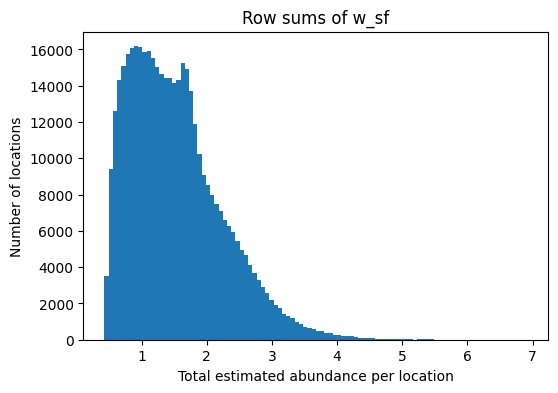

count    427296.000000
mean          1.524333
std           0.716342
min           0.427586
25%           0.962697
50%           1.415327
75%           1.928105
max           6.917683
dtype: float64


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

total_abundance = means_df.sum(axis=1)

plt.figure(figsize=(6,4))
plt.hist(total_abundance, bins=100)
plt.xlabel("Total estimated abundance per location")
plt.ylabel("Number of locations")
plt.title("Row sums of w_sf")
plt.show()

print(total_abundance.describe())

                           B/T_cell    B_cell  CAR_T_cell        DC  \
F07839_cellid_000000001-1  0.065726  0.085413    0.164130  0.072238   
F07839_cellid_000000002-1  0.089044  0.083083    0.085122  0.063525   
F07839_cellid_000000004-1  0.037420  0.045071    0.074761  0.064707   
F07839_cellid_000000005-1  0.051481  0.084681    0.069925  0.079881   
F07839_cellid_000000006-1  0.081824  0.086596    0.076662  0.107650   

                           Endothelial  
F07839_cellid_000000001-1     0.060742  
F07839_cellid_000000002-1     0.064987  
F07839_cellid_000000004-1     0.084263  
F07839_cellid_000000005-1     0.053767  
F07839_cellid_000000006-1     0.077164  


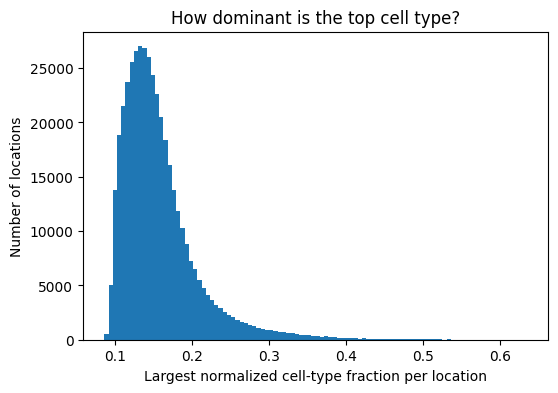

In [16]:
rel_df = means_df.div(means_df.sum(axis=1).replace(0, np.nan), axis=0)

print(rel_df.iloc[:5, :5])

plt.figure(figsize=(6,4))
plt.hist(rel_df.max(axis=1), bins=100)
plt.xlabel("Largest normalized cell-type fraction per location")
plt.ylabel("Number of locations")
plt.title("How dominant is the top cell type?")
plt.show()

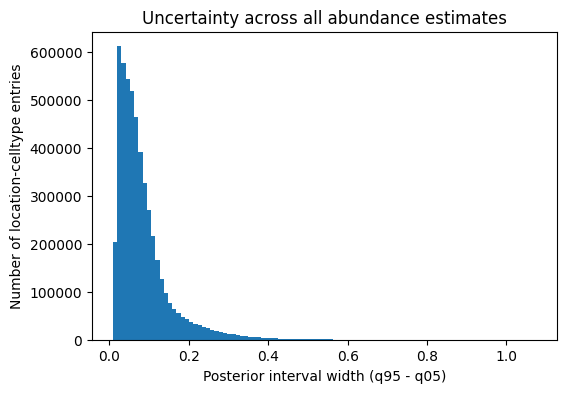

            B/T_cell         B_cell     CAR_T_cell             DC  \
count  427296.000000  427296.000000  427296.000000  427296.000000   
mean        0.044647       0.079067       0.198424       0.048520   
std         0.021902       0.037199       0.104582       0.021302   
min         0.009602       0.013241       0.023720       0.009581   
25%         0.026313       0.047522       0.120696       0.031728   
50%         0.040815       0.077058       0.180882       0.046694   
75%         0.059096       0.105331       0.254433       0.062513   
max         0.249091       0.345842       1.073921       0.241677   

         Endothelial    Erythrocyte     Fibroblast     Macrophage  \
count  427296.000000  427296.000000  427296.000000  427296.000000   
mean        0.053064       0.134156       0.069933       0.050473   
std         0.026591       0.075592       0.037753       0.024453   
min         0.009585       0.021876       0.009744       0.008939   
25%         0.030449       0.0770

In [17]:
uncertainty_df = q95_df - q05_df

plt.figure(figsize=(6,4))
plt.hist(uncertainty_df.to_numpy().ravel(), bins=100)
plt.xlabel("Posterior interval width (q95 - q05)")
plt.ylabel("Number of location-celltype entries")
plt.title("Uncertainty across all abundance estimates")
plt.show()

print(uncertainty_df.describe())

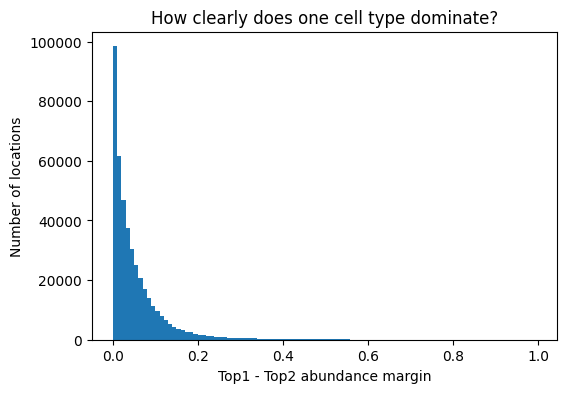

Erythrocyte    87019
Fibroblast     86297
CAR_T_cell     83259
Neutrophils    60296
NK_cell        39676
Macrophage     26537
Monocyte       20190
Endothelial    14902
T_cell          3855
B_cell          3820
B/T_cell         885
DC               560
Name: count, dtype: int64


In [18]:
top_ct = means_df.idxmax(axis=1)
top_val = means_df.max(axis=1)

# second-best value
arr = means_df.to_numpy()
second_val = np.partition(arr, -2, axis=1)[:, -2]
margin = top_val.values - second_val

plt.figure(figsize=(6,4))
plt.hist(margin, bins=100)
plt.xlabel("Top1 - Top2 abundance margin")
plt.ylabel("Number of locations")
plt.title("How clearly does one cell type dominate?")
plt.show()

print(pd.Series(top_ct).value_counts().head(20))